In [1]:
import numpy as np  # Linear algebra
import pandas as pd  # Data processing, CSV file I/O
import tensorflow as tf
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from sklearn.model_selection import train_test_split
import os
import matplotlib.pyplot as plt

In [7]:
# Set directory path for dataset
xray_dir = "/content/drive/MyDrive/Colab Notebooks/COVID/images"


In [8]:
# Load images
x_data = []
for filename in os.listdir(xray_dir):
    if filename.endswith(".png"):
        img_path = os.path.join(xray_dir, filename)
        img = load_img(img_path, target_size=(60, 60), color_mode="grayscale")
        img_array = img_to_array(img)
        x_data.append(img_array)


In [9]:
# Convert pixel values to range 0 to 1
x_data = np.array(x_data) / 255.0

In [10]:
# Split dataset into training and validation sets
x_train, x_val = train_test_split(x_data, test_size=0.33, random_state=42)

In [11]:
# Define input shape
input_shape = (60, 60, 1)

In [12]:
# Encoder model
encoder = tf.keras.models.Sequential([
    tf.keras.layers.Conv2D(16, (3, 3), activation='relu', padding='same', input_shape=input_shape),
    tf.keras.layers.MaxPooling2D((2, 2), padding='same'),
    tf.keras.layers.Conv2D(8, (3, 3), activation='relu', padding='same'),
    tf.keras.layers.MaxPooling2D((2, 2), padding='same'),
    tf.keras.layers.Conv2D(8, (3, 3), activation='relu', padding='same'),
    tf.keras.layers.MaxPooling2D((2, 2), padding='same')
])


/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [13]:
# Decoder model
decoder = tf.keras.models.Sequential([
    tf.keras.layers.Conv2D(8, (3, 3), activation='relu', padding='same'),
    tf.keras.layers.UpSampling2D((2, 2)),
    tf.keras.layers.Conv2D(8, (3, 3), activation='relu', padding='same'),
    tf.keras.layers.UpSampling2D((2, 2)),
    tf.keras.layers.Conv2D(16, (3, 3), activation='relu'),
    tf.keras.layers.UpSampling2D((2, 2)),
    tf.keras.layers.Conv2D(1, (3, 3), activation='sigmoid', padding='same')
])

In [14]:
# Build Autoencoder model
autoencoder = tf.keras.models.Sequential([encoder, decoder])

In [15]:
# Compile Autoencoder model
autoencoder.compile(optimizer='adam', loss='binary_crossentropy')

In [16]:
# Train Autoencoder model
autoencoder.fit(x_train, x_train, epochs=10, batch_size=32, validation_data=(x_val, x_val))

Epoch 1/10
76/76 ━━━━━━━━━━━━━━━━━━━━ 22s 240ms/step - loss: 0.6652 - val_loss: 0.5857
Epoch 2/10
76/76 ━━━━━━━━━━━━━━━━━━━━ 18s 217ms/step - loss: 0.5863 - val_loss: 0.5747
Epoch 3/10
76/76 ━━━━━━━━━━━━━━━━━━━━ 20s 204ms/step - loss: 0.5760 - val_loss: 0.5707
Epoch 4/10
76/76 ━━━━━━━━━━━━━━━━━━━━ 21s 217ms/step - loss: 0.5745 - val_loss: 0.5691
Epoch 5/10
76/76 ━━━━━━━━━━━━━━━━━━━━ 23s 250ms/step - loss: 0.5712 - val_loss: 0.5670
Epoch 6/10
76/76 ━━━━━━━━━━━━━━━━━━━━ 19s 235ms/step - loss: 0.5698 - val_loss: 0.5658
Epoch 7/10
76/76 ━━━━━━━━━━━━━━━━━━━━ 17s 192ms/step - loss: 0.5705 - val_loss: 0.5644
Epoch 8/10
76/76 ━━━━━━━━━━━━━━━━━━━━ 20s 181ms/step - loss: 0.5680 - val_loss: 0.5632
Epoch 9/10
76/76 ━━━━━━━━━━━━━━━━━━━━ 22s 204ms/step - loss: 0.5696 - val_loss: 0.5628
Epoch 10/10
76/76 ━━━━━━━━━━━━━━━━━━━━ 19s 187ms/step - loss: 0.5680 - val_loss: 0.5619


In [17]:
# Perform image reconstruction
reconstructed_images = autoencoder.predict(x_data)


113/113 ━━━━━━━━━━━━━━━━━━━━ 5s 39ms/step


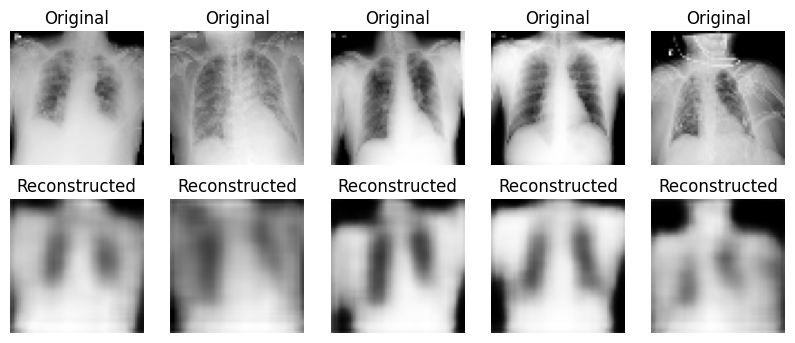

In [18]:
# Visualize original and reconstructed images
n = 5  # Number of images to display
plt.figure(figsize=(10, 4))
for i in range(n):
    # Original image
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(x_data[i].squeeze(), cmap='gray')
    plt.title('Original')
    plt.axis('off')

    # Reconstructed image
    ax = plt.subplot(2, n, i + 1 + n)
    plt.imshow(reconstructed_images[i].squeeze(), cmap='gray')
    plt.title('Reconstructed')
    plt.axis('off')
plt.show()

In [19]:
# Anomaly Detection
# Calculate reconstruction error
reconstruction_errors = np.mean(np.square(x_data - reconstructed_images), axis=(1, 2, 3))

In [20]:
# Define threshold for anomaly detection
threshold = np.percentile(reconstruction_errors, 95)
anomalies = reconstruction_errors > threshold


In [21]:
print("Number of anomalies detected:", np.sum(anomalies))


Number of anomalies detected: 181
